# Team project

## Import necessary library

`numpy`: to use the array concept and time optimization since it underlayer code use C
mathpli

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random #Generate random number for array size
np.set_printoptions(threshold = 300)
import time

### (a) Algorithm implementation

### The `swap` function

The `swap` function allow to swap position of 2 number in the array in `insertionSort()` function:

In [2]:
def swap(ar, idx1, idx2):
    """
    Arguments:
        ar (np.array)   : an array that need to swap 2 keys (values)
        idx1, idx2 (int): 2 indexes of the keys that need to swap
        
    Return:
        None
    """
    
    ar[idx1], ar[idx2] = ar[idx2], ar[idx1]

### `insertionSort` implementation

Our implementation of the `insertionSort()` taught in the lecture:

In [3]:
def insertionSort(ar, keyC, start, end):
    '''
    Arguments:
        ar (np.array): array need to be sorted using insertion sort
        keyC (int)   : number of key comparisons before this step
        start (int)  : a start position to sort
        end (int)    : the end position (NOT the size of the array)
        
    Return:
        keyC (int)   : number of key comparisons after this step
    '''
    
    if start >= end:
        return keyC
    
    for i in range(start, end + 1):
        for j in range(i, start, -1):
            if ar[j] < ar[j - 1]:
                keyC += 1
                swap(ar, j, j - 1)
            else:
                keyC += 1
                break
    return keyC

### `merge` implementation

Our implementation of the `merge()` taught in the lecture:

In [4]:
def merge(ar, keyC, start, mid, end):
    """
    Arguments:
        ar (np.array): array need to be merged during mergesort using merge sort
        keyC (int)   : number of key comparisons befor this step
        start (int)  : the start of the array
        mid (int)    : the mid of the array
        end (int)    : the end of the array (INCLUSIVE!)
        INTUITION:
            start   => mid : a sorted array ar1
            mid + 1 => end : a sorted array ar2
            We need to merged 2 array ar1, ar2 into one array ar.
            || This implementation help reduce the space complexity!
    
    Return:
        keyC (int)   : number of key comparisons after this step
    """
    
    # Trivial case
    if start >= end:
        return keyC
    
    # Size of the sorted array 
    sorted_size = end - start + 1
    
    # Initialize temp array
    sorted_arr = np.zeros(sorted_size) 
    
    # pointer index of the first array
    idx1 = start                       
    
    # pointer index of the second array
    idx2 = mid + 1                     
    loop = True
    
    # pointer index of the temp array
    i = 0                              
    
    while loop:
        
        if ar[idx1] < ar[idx2]:
            keyC += 1
            
            # If the value of the ar1 at idx1 is larger, insert it in the temp array
            sorted_arr[i] = ar[idx1]
            
            # Increase the temp array's pointer index to the empty slot
            # sorted_arr: [value] [] [] ... =>  temp_ar: [value] [] [] ...
            #                ^                                   ^
            #                i                                 i + 1
            i += 1
            
            
            
            # If the ar1's pointer hit the end but ar2's pointer have not reached the end
            # ar1: [.] [.] [.] ... [.] AND ar2: [.] [.] [.] ... [.] ... [.]
            #                       ^                            ^
            #                 idx1 == mid                  idx2 != end
            # So we have to loop and insert all the remaining elements in ar2
            if idx1 == mid:
                
                # Loop until ar2's pointer hit the end.
                while(idx2 <= end):
                    sorted_arr[i] = ar[idx2]
                    i += 1
                    idx2 += 1
                
                # After inserted all the elements in both array into 1 array we break the main loop
                break
            
            # If the ar1's pointer have not reached the end, increase its pointer
            # ar1: [.] [.] [.] ... [.] [.] ... => [.] [.] [.] ... [.] [.] ...
            #                       ^                                  ^
            #                      idx1                             idx1 + 1
            else:
                idx1 += 1
            
        else:
            # Same intuition for the above code but for ar2!
            
            keyC += 1
            sorted_arr[i] = ar[idx2]
            i += 1
            if idx2 == end:
                
                while(idx1 <= mid):
                    sorted_arr[i] = ar[idx1]
                    i += 1
                    idx1 += 1
                    
                break
            else:
                idx2 += 1
    
    # Assigned temperary merged array into the main array with corresponding positions.
    ar[start:end + 1] = sorted_arr
    return keyC

### Dynamic `mergeSort` implementation

This mergeSort adds an extra argument from the original `mergeSort()` taught in the lectures, this will allow us to set an 'S' value (min2insertion). 'S' value of zero is simply the original mergeSort() from the lectures

In [5]:
def dynamicMergeSort(ar, keyC, start, end, min2insertion = 0):
    '''
    Arguments:
        ar (np.array)       : array need to be merged during mergesort using merge sort
        keyC (int)          : number of key comparisons befor this step
        start (int)         : the start of the array
        mid (int)           : the mid of the array
        end (int)           : the end of the array (INCLUSIVE!)
        min2insertion (int) : the minimum size of partitioned array that change into insertion Sort
    
    Return:
        keyC (int)          : number of key comparition after this step
    '''
    
    
    

    # If the size of the array need to be sorted smaller then a required value
    # => insertionSort()

    if (end - start + 1) <= min2insertion:
        keyC = insertionSort(ar, keyC, start, end)
        return keyC
    
    # Trivial case
    if (start >= end):
        return keyC
    
    else:
        mid = (start + end) // 2
        
        # partition the main array into 2 smaller array
        keyC = dynamicMergeSort(ar, keyC, start, mid, min2insertion) # The left part
        keyC = dynamicMergeSort(ar, keyC, mid + 1, end, min2insertion) # The right part
        
        # Merge 2 sorted array to the main array
        keyC = merge(ar, keyC, start, mid, end)
        return keyC

### (b) Generate input data

Generate arrays of increasing sizes, in a range from
1,000 to 10 million. For each of the sizes, generate a random dataset of integers
in the range of [1, …, x], where x is the largest number you allow for your
datasets

In [6]:
def generateInput(arrCount = 1, n = 100_000, stepSize = 10_000, testing = True):
    """
    Arguments:
        arrCount (int) : number of arrays need to generate
        n (int)        : size of the first array to generate
        stepSize (int) : the size difference between two adjacent arrays generated.
    
    Return:
        An numpy array if arrCount == 1
        List of numpy array if arrCount > 1
    """
    
    # This line is to asure of the consistency of the graph plot below
    if testing:
        np.random.seed(0) 
    
    # This line is to asure that the generated arrays' size cannot be larger then 10,000,000
    stepSize %= 10_000_000
    
    # List of generated arrays
    arrays = []
    
    if arrCount == 1:
        return [np.random.randint(low = 1, high = n + 1, size = n)]
    
    for i in range(arrCount):
        arrays.append(np.random.randint(low = 1, high = n + 1, size = n))
        n += stepSize
        
    return arrays

#### Test cell

In [7]:
# Section to check if generateInput is working
a = generateInput(10)

for i in range(len(a)):
    step = 10_000
    N = 100_000
    print("Array[{}]: {}".format(i, a[i]))
    print("Array length: {:,}\n".format(len(a[i])))
    assert (a[i].size == N + i * step), f"Expect array size {N + i * step}, but get {a[i].size}"
    

# Clear the test memory to avoid affecting other cells
del a
del step
del N

Array[0]: [68269 43568 42614 ... 36810 61447 63718]
Array length: 100,000

Array[1]: [82133 20719 91835 ... 84217 18714 58771]
Array length: 110,000

Array[2]: [62689 91872 23167 ... 68902 81939 12842]
Array length: 120,000

Array[3]: [ 62637 122959  23694 ...  96956  90167  68309]
Array length: 130,000

Array[4]: [81951 93348 40561 ... 20838 87127 38249]
Array length: 140,000

Array[5]: [110066 100165  24102 ... 140981  93800  82786]
Array length: 150,000

Array[6]: [ 49718 126806  22538 ... 136994 137347 137651]
Array length: 160,000

Array[7]: [ 99713  45935 154250 ...  68845  58139  41246]
Array length: 170,000

Array[8]: [144699 103834 155653 ...  13919 154613  49625]
Array length: 180,000

Array[9]: [  1460  89403 110472 ...   9935    207 158837]
Array length: 190,000



### (c) Analyse time complexity

    i. Given a fixed S value, plot the no. of key comparisons over different sizes of input list n
    
    ii. Given a fixed n size, plot the no. of key comparisons over different values of S.
    
    iii. Using different sizes of input datasets, determine the most optimal value for S.

#### Key Comparison Test
Quick test to see if key comparisons have been implemented correctly for 2 algorithms: <br>
* Merge Sort: S = 0
* Insertion Sort: S = length of the array

In [8]:
# Test to check if key comparisons are correctly implemented (test arrays are from the Tutorials)
test = np.array([14,40,31,28,3,15,17,51])

# Test mergeSort
c = 0
c = dynamicMergeSort(ar    = test, 
                     keyC  = c, 
                     start = 0, 
                     end   = len(test) - 1,
                     min2insertion = 0) # min2insertion is initialize to 0 in the function

print("After sorting: {}".format(test))

expect_sorted = np.array([3, 14, 15, 17, 28, 31, 40, 51])
assert (all(test == expect_sorted)), f"Expect {expect_sorted} but get {test}"

print("Key comparisons: {}\n".format(c))

# Compute the merge sort by hands
# Denote key comparison: kc
# Initially:              14   40   31   28   3   15   17 51                  

# Partition:            (14   40   31   28) | (3   15   17 51)                [0 key comparisons]

# Partition:         (14   40) || (31   28) | (3   15) || (17 51)             [0 key comparisons]

# Partition: (14) ||| (40) || (31) ||| (28) | (3) ||| (15) || (17) ||| (51)   [0 key comparisons]

# Merge:             (14   40) || (28   31) | (3   15) || (17 51)             [4 key comparisons]
# |# ks|:               1 kc         1kc         1kc        1kc

# Merge:                (14   28   31   40) | (3   15   17 51)                [5 key comparisons]
# |# ks|:                     3kcs                   2kcs

# Merge:                  3   14   15   17   28   31   40   51                [7 key comparisons]
# |# ks|:                                7kcs

# 4 + 5 + 7 = 16 (key comparisons)

assert (c == 16), f"Expect 16 but get {c}"



# Similarly test insertionSort

test = np.array([5,4,3,2,1,0])
c = 0
c = dynamicMergeSort(ar    = test, 
                     keyC  = c, 
                     start = 0, 
                     end   = len(test)-1, 
                     min2insertion = test.size)

print("After sorting: {}".format(test))

expect_sorted = np.array([0,1,2,3,4,5])
assert (all(test == expect_sorted)), f"Expect {expect_sorted} but get {test}"

print("Key comparisons: {}".format(c))

# 1 + 2 + 3 + 4 + 5 = 15 (key comparisons) [Worst case in insertionSort]
assert (c == 15), f"Expect 15 but get {c}"

# Clear test memory
del test
del c
del expect_sorted

After sorting: [ 3 14 15 17 28 31 40 51]
Key comparisons: 16

After sorting: [0 1 2 3 4 5]
Key comparisons: 15


### c) i) Fixed S

We can change THIS cell values to try for different experiments in the adjacent cell

In [9]:
numOfArrays = 100
startSize = 1_000
stepSize = 1_000

s = 6

C:\Users\moham\AppData\Local\Temp\ipykernel_1804\766721034.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in x_values])
C:\Users\moham\AppData\Local\Temp\ipykernel_1804\766721034.py:36: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in y_values])


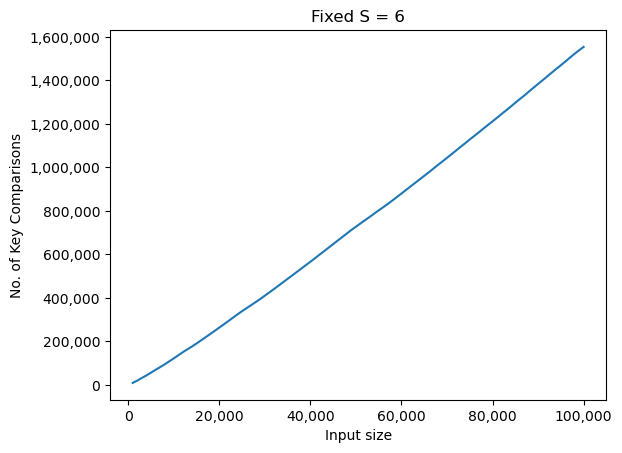

Array[0]: Input Size(n)= 1,000 Key Comparisons= 8,751
Array[1]: Input Size(n)= 2,000 Key Comparisons= 19,476
Array[2]: Input Size(n)= 3,000 Key Comparisons= 31,567
Array[3]: Input Size(n)= 4,000 Key Comparisons= 43,015
Array[4]: Input Size(n)= 5,000 Key Comparisons= 55,793
Array[5]: Input Size(n)= 6,000 Key Comparisons= 68,962
Array[6]: Input Size(n)= 7,000 Key Comparisons= 81,150
Array[7]: Input Size(n)= 8,000 Key Comparisons= 94,004
Array[8]: Input Size(n)= 9,000 Key Comparisons= 107,758
Array[9]: Input Size(n)= 10,000 Key Comparisons= 121,430
Array[10]: Input Size(n)= 11,000 Key Comparisons= 135,631
Array[11]: Input Size(n)= 12,000 Key Comparisons= 150,095
Array[12]: Input Size(n)= 13,000 Key Comparisons= 163,177
Array[13]: Input Size(n)= 14,000 Key Comparisons= 176,161
Array[14]: Input Size(n)= 15,000 Key Comparisons= 189,928
Array[15]: Input Size(n)= 16,000 Key Comparisons= 204,303
Array[16]: Input Size(n)= 17,000 Key Comparisons= 218,850
Array[17]: Input Size(n)= 18,000 Key Compa

In [10]:
# Generate array of increasing array sizes
inputArray = generateInput(numOfArrays, startSize, stepSize)

# The history list to store the size of each array
sizes = []

# The history list to store the key comparisons after sorting for each array
keyComparisons = []


# The min size of array to change to insertion sort
S = s

# Main loop to sort the input array
for i in range(len(inputArray)): 
    
    
    sizes.append(len(inputArray[i]))
    comparisons = 0   
    comparisons = dynamicMergeSort(ar = inputArray[i], 
                                   keyC = comparisons, 
                                   start = 0, 
                                   end = len(inputArray[i]) - 1, 
                                   min2insertion = S)
    keyComparisons.append(comparisons) # Record the history of the key comparisons

# Plotting the graph for input size vs no. of key comparisons
plt.plot(sizes, keyComparisons)
plt.title("Fixed S = {}".format(S))
plt.xlabel("Input size")
plt.ylabel("No. of Key Comparisons")

x_values = plt.gca().get_xticks()
plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in x_values])
y_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in y_values])

plt.show()

# Loop to show the mapping of each array and their key comparisons
for i in range(len(inputArray)):
    print("Array[{}]: Input Size(n)= {:,} Key Comparisons= {:,}".format(i, sizes[i], keyComparisons[i]))
print(f"Last sorted array {inputArray[i - 1]}")

$$Total= n(\log_{2}{\frac{n}{s}} - 1) - (\frac{n}{s}-1) + \frac{ns}{2} - \frac{n}{2}$$ (Refer the below proof)

### c)ii) Fixed input size n = 100,000

Modify this cell to test for the next cell

In [24]:
n = 100_000
startS = 2
stepSize = 2
numArray = 1

Array[0]: [68269 43568 42614 ... 36810 61447 63718]
Array[1]: [68269 43568 42614 ... 36810 61447 63718]
Array[2]: [68269 43568 42614 ... 36810 61447 63718]
Array[3]: [68269 43568 42614 ... 36810 61447 63718]
Array[4]: [68269 43568 42614 ... 36810 61447 63718]
Array[5]: [68269 43568 42614 ... 36810 61447 63718]
Array[6]: [68269 43568 42614 ... 36810 61447 63718]
Array[7]: [68269 43568 42614 ... 36810 61447 63718]
Array[8]: [68269 43568 42614 ... 36810 61447 63718]
Array[9]: [68269 43568 42614 ... 36810 61447 63718]


C:\Users\moham\AppData\Local\Temp\ipykernel_1804\1189374852.py:37: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in x_values])


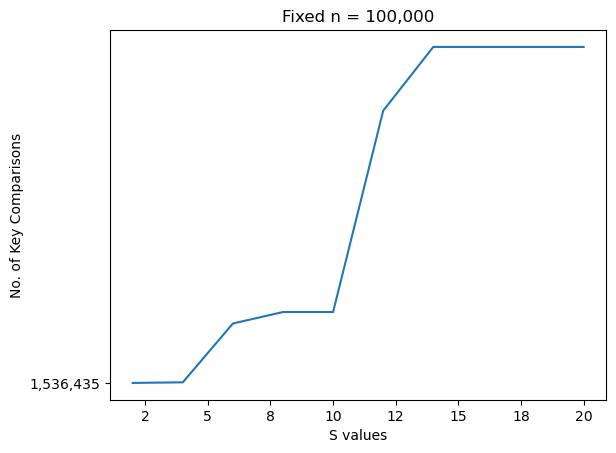

LEN: 100000
Array[0]: S Value= 2 Key Comparisons= 1,536,435
Array[1]: S Value= 4 Key Comparisons= 1,536,620
Array[2]: S Value= 6 Key Comparisons= 1,554,656
Array[3]: S Value= 8 Key Comparisons= 1,558,174
Array[4]: S Value= 10 Key Comparisons= 1,558,174
Array[5]: S Value= 12 Key Comparisons= 1,619,907
Array[6]: S Value= 14 Key Comparisons= 1,639,469
Array[7]: S Value= 16 Key Comparisons= 1,639,469
Array[8]: S Value= 18 Key Comparisons= 1,639,469
Array[9]: S Value= 20 Key Comparisons= 1,639,469
Last sorted array: [68269 43568 42614 ... 36810 61447 63718]


In [25]:
s = startS
# Generating an list of increasing S values
sValues = []

for i in range(10): 
    sValues.append(s)
    s += 2

# Main loop to sort 10 arrays with the same array size n=100,000, but with increasing S values
keyComparisons = []
inputArray = generateInput(arrCount = numArray, 
                           n = n,
                           stepSize = 0,
                           testing = True)

for i in range(10):
    print("Array[{}]: {}".format(i, inputArray[0]))
    a = np.copy(inputArray[0])
    comparisons = 0
    comparisons = dynamicMergeSort(a, 
                                   comparisons, 
                                   0, 
                                   len(a) - 1, 
                                   sValues[i])
    keyComparisons.append(comparisons)

#Plotting the graph for input size vs no. of key comparisons
plt.plot(sValues, keyComparisons)
plt.title("Fixed n = {:,}".format(n))
plt.xlabel("S values")
plt.ylabel("No. of Key Comparisons")

#Change step size of axes
plt.yticks(np.arange(min(keyComparisons), max(keyComparisons) + 1, 250_000))

x_values = plt.gca().get_xticks()
plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in x_values])
y_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in y_values])

plt.show()

print("LEN: {}".format(len(inputArray[0])))
#Loop to show the mapping of each array and their key comparisons
for i in range(10):
    print("Array[{}]: S Value= {:,} Key Comparisons= {:,}".format(i, sValues[i], keyComparisons[i]))
print(f"Last sorted array: {inputArray[numArray - 1]}")

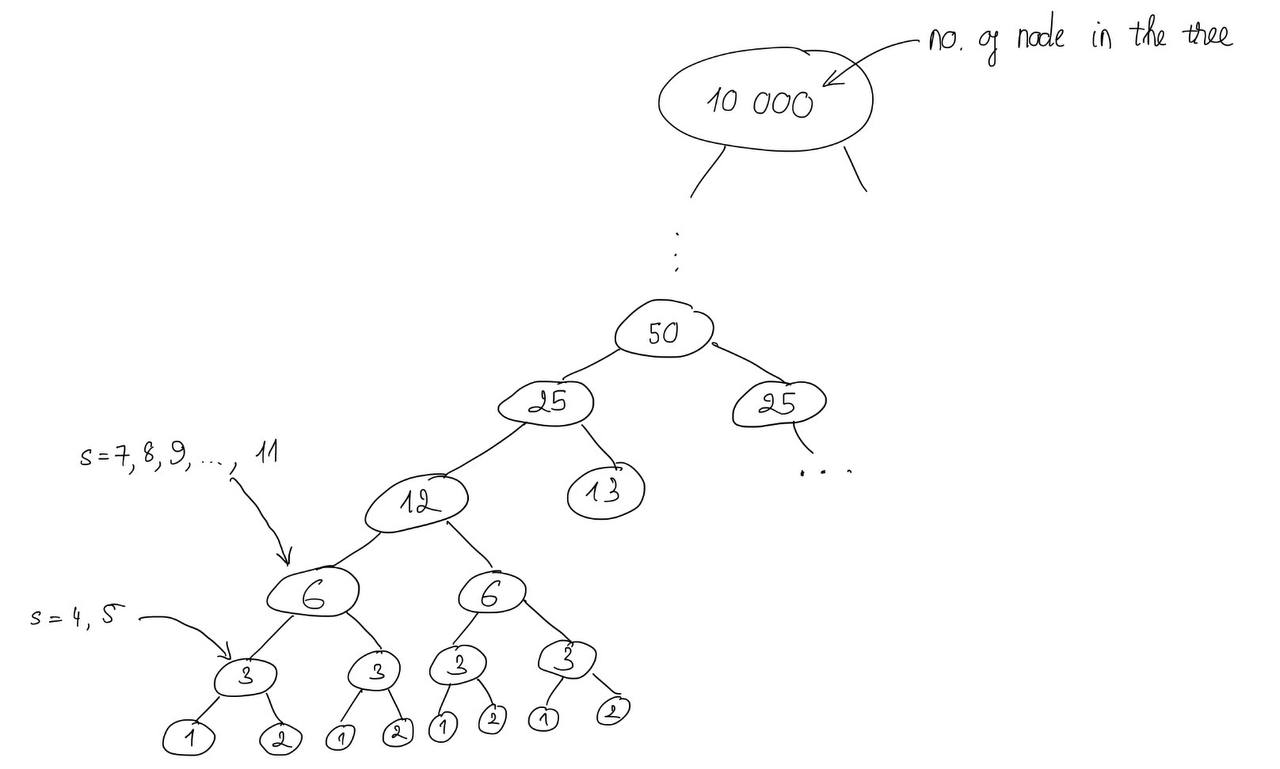

### c)iii) Determining the most optimal S value

#### Array size n <br>
* With the minimum size s of the sub-array that change to `insertionSort()` we can determine the depth k of the subarray in the tree<br>
 $$s = \frac{a}{2^{k}}$$
 $$$$
 
* Number of key comparisons for the worst case of the `insertionSort()` will result in 
 $$\frac{s(s-1)}{2}$$

* Number of sub-arrays at depth k is: $ \,2^{k} \, \, \, \, \, \, \, \, (1)$ <br><br>

* Total number of key comparison for all `insertionSort()` for all sub-arrays at depth k is:
$$\frac{n}{s}\cdot \frac{s(s-1)}{2} $$
$$$$
$$= \frac{ns}{2} - \frac{n}{2}  \, \, \, \, \, \, \, \, (2)$$
$$$$

* From (1) we can find the number of pairs of sub-arrays at depth k is 
$$\frac{n}{2s}$$
$$$$


* Number of comparisons for `merge()` sub-arrays at depth k to depth k - 1:<br>
Total number of elements in 2 sub-arrays size $s$ is $2s$ so the worst case in merging 2 arrays is $(2s - 1)$ but there are $\frac{n}{2s}$ pairs at k depth:
$$(2s-1)\cdot\frac{n}{2s} = n - \frac{n}{2s}$$
$$$$
$$= n - 2^{k-1}$$

* Similarly we can observe and see that to merge sub arrays to depth $i$ has the no. of key comparisons is:
$$$$
$$n - 2^{i}$$

* The total key comparisons to merge all the sub-array in the tree is:
$$\sum_{i = 0}^{k-1}(n - 2^{i}) = (k-1)n - (1+2+ ...+ 2^{k-1}) = (k-1)n - (2^{k} - 1)$$ 
$$$$
$$= (\log_{2}{\frac{n}{s}} - 1) - (\frac{n}{s}-1) \, \, \, \, \, \, \, \, (3)$$
$$$$
* From (2) and (3) we can sum up the total of key comparisons:
$$Total= n(\log_{2}{\frac{n}{s}} - 1) - (\frac{n}{s}-1) + \frac{ns}{2} - \frac{n}{2}$$

* The derivate of the above function is:
$$Total' = -\frac{n}{sln2} + \frac{n}{s^{2}}+\frac{n}{2} = n\cdot(-\frac{1}{sln2} + \frac{1}{s^{2}}+\frac{1}{2})$$\

* Let $x = \frac{1}{s}$, $Total' = 0$ and solve the equation:
$$n\cdot(-\frac{x}{ln2} + x^{2} + \frac{1}{2}) = 0 \Rightarrow x_{1} = 0.86397\, \, \, and\, \, \, x_{2} = 0.57872$$
$$\Rightarrow s_{1} = 1.15745 \,\,\, and \,\,\, s_{2} = 1.727951$$
$$$$

* If we subtitute back the two value of S we will find out that $s_{2}$ will result in smaller value
$$\therefore \,\,\, s \approx 2$$
will help to optimize the algorithm.


### We can check the result with the above value to see the difference

In [13]:
numOfArrays = 100
startSize = 1_000
stepSize = 1_000

s = 2

C:\Users\moham\AppData\Local\Temp\ipykernel_1804\766721034.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in x_values])
C:\Users\moham\AppData\Local\Temp\ipykernel_1804\766721034.py:36: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in y_values])


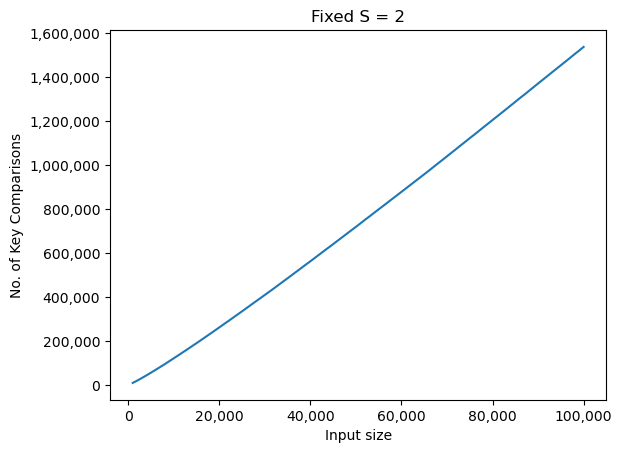

Array[0]: Input Size(n)= 1,000 Key Comparisons= 8,720
Array[1]: Input Size(n)= 2,000 Key Comparisons= 19,372
Array[2]: Input Size(n)= 3,000 Key Comparisons= 30,932
Array[3]: Input Size(n)= 4,000 Key Comparisons= 42,835
Array[4]: Input Size(n)= 5,000 Key Comparisons= 55,228
Array[5]: Input Size(n)= 6,000 Key Comparisons= 67,872
Array[6]: Input Size(n)= 7,000 Key Comparisons= 80,711
Array[7]: Input Size(n)= 8,000 Key Comparisons= 93,563
Array[8]: Input Size(n)= 9,000 Key Comparisons= 106,962
Array[9]: Input Size(n)= 10,000 Key Comparisons= 120,475
Array[10]: Input Size(n)= 11,000 Key Comparisons= 134,035
Array[11]: Input Size(n)= 12,000 Key Comparisons= 147,766
Array[12]: Input Size(n)= 13,000 Key Comparisons= 161,336
Array[13]: Input Size(n)= 14,000 Key Comparisons= 175,437
Array[14]: Input Size(n)= 15,000 Key Comparisons= 189,308
Array[15]: Input Size(n)= 16,000 Key Comparisons= 203,411
Array[16]: Input Size(n)= 17,000 Key Comparisons= 217,682
Array[17]: Input Size(n)= 18,000 Key Compa

In [14]:
# Generate array of increasing array sizes
inputArray = generateInput(numOfArrays, startSize, stepSize)

# The history list to store the size of each array
sizes = []

# The history list to store the key comparisons after sorting for each array
keyComparisons = []


# The min size of array to change to insertion sort
S = s

# Main loop to sort the input array
for i in range(len(inputArray)): 
    
    
    sizes.append(len(inputArray[i]))
    comparisons = 0   
    comparisons = dynamicMergeSort(ar = inputArray[i], 
                                   keyC = comparisons, 
                                   start = 0, 
                                   end = len(inputArray[i]) - 1, 
                                   min2insertion = S)
    keyComparisons.append(comparisons) # Record the history of the key comparisons

# Plotting the graph for input size vs no. of key comparisons
plt.plot(sizes, keyComparisons)
plt.title("Fixed S = {}".format(S))
plt.xlabel("Input size")
plt.ylabel("No. of Key Comparisons")

x_values = plt.gca().get_xticks()
plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in x_values])
y_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in y_values])

plt.show()

# Loop to show the mapping of each array and their key comparisons
for i in range(len(inputArray)):
    print("Array[{}]: Input Size(n)= {:,} Key Comparisons= {:,}".format(i, sizes[i], keyComparisons[i]))
print(f"Last sorted array {inputArray[i - 1]}")

In [15]:
numOfArrays = 100
startSize = 1_000
stepSize = 1_000

s = 3

C:\Users\moham\AppData\Local\Temp\ipykernel_1804\766721034.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in x_values])
C:\Users\moham\AppData\Local\Temp\ipykernel_1804\766721034.py:36: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in y_values])


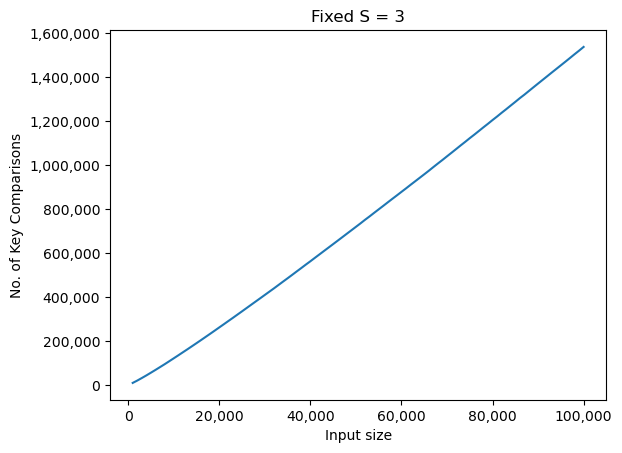

Array[0]: Input Size(n)= 1,000 Key Comparisons= 8,711
Array[1]: Input Size(n)= 2,000 Key Comparisons= 19,379
Array[2]: Input Size(n)= 3,000 Key Comparisons= 30,925
Array[3]: Input Size(n)= 4,000 Key Comparisons= 42,834
Array[4]: Input Size(n)= 5,000 Key Comparisons= 55,253
Array[5]: Input Size(n)= 6,000 Key Comparisons= 67,811
Array[6]: Input Size(n)= 7,000 Key Comparisons= 80,681
Array[7]: Input Size(n)= 8,000 Key Comparisons= 93,556
Array[8]: Input Size(n)= 9,000 Key Comparisons= 106,970
Array[9]: Input Size(n)= 10,000 Key Comparisons= 120,441
Array[10]: Input Size(n)= 11,000 Key Comparisons= 133,994
Array[11]: Input Size(n)= 12,000 Key Comparisons= 147,740
Array[12]: Input Size(n)= 13,000 Key Comparisons= 161,415
Array[13]: Input Size(n)= 14,000 Key Comparisons= 175,369
Array[14]: Input Size(n)= 15,000 Key Comparisons= 189,331
Array[15]: Input Size(n)= 16,000 Key Comparisons= 203,414
Array[16]: Input Size(n)= 17,000 Key Comparisons= 217,702
Array[17]: Input Size(n)= 18,000 Key Compa

In [16]:
# Generate array of increasing array sizes
inputArray = generateInput(numOfArrays, startSize, stepSize)

# The history list to store the size of each array
sizes = []

# The history list to store the key comparisons after sorting for each array
keyComparisons = []


# The min size of array to change to insertion sort
S = s

# Main loop to sort the input array
for i in range(len(inputArray)): 
    
    
    sizes.append(len(inputArray[i]))
    comparisons = 0   
    comparisons = dynamicMergeSort(ar = inputArray[i], 
                                   keyC = comparisons, 
                                   start = 0, 
                                   end = len(inputArray[i]) - 1, 
                                   min2insertion = S)
    keyComparisons.append(comparisons) # Record the history of the key comparisons

# Plotting the graph for input size vs no. of key comparisons
plt.plot(sizes, keyComparisons)
plt.title("Fixed S = {}".format(S))
plt.xlabel("Input size")
plt.ylabel("No. of Key Comparisons")

x_values = plt.gca().get_xticks()
plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in x_values])
y_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in y_values])

plt.show()

# Loop to show the mapping of each array and their key comparisons
for i in range(len(inputArray)):
    print("Array[{}]: Input Size(n)= {:,} Key Comparisons= {:,}".format(i, sizes[i], keyComparisons[i]))
print(f"Last sorted array {inputArray[i - 1]}")

### d) Comparing our mergeSort(Optimal S) with lecture mergeSort
We will be comparing the same input array of size 10,000,000 to compare their performance

In [19]:
#Generate input array of size 10,000,000
n = 10_000_000
inputArray = generateInput(arrCount = 1, 
                           n = n,
                           stepSize = 0,
                           testing = True)
ourArray = np.copy(inputArray)[0]
lecArray = np.copy(inputArray)[0]

#### i) Our mergeSort with the Optimal S value of 2

In [20]:
#Function body to calculate the number of key comparisons using our implemented dynamicMergesort
S = 2

print("Array before sorting: {}".format(ourArray))
keyComparisons = 0
current_time = time.time()
keyComparisons = dynamicMergeSort(ar = ourArray, 
                                   keyC = keyComparisons, 
                                   start = 0, 
                                   end = len(ourArray) - 1, 
                                   min2insertion = S)
end_time = time.time()
time_taken = end_time - current_time

print("Array after sorting: {}".format(ourArray))
print("Key Comparisons: {}".format(keyComparisons))
print("Time Taken : {}".format(time_taken))

Array before sorting: [8325805 1484406 2215105 ...  978527 7965346 4997825]
Array after sorting: [      3       3       4 ... 9999993 9999994 9999995]
Key Comparisons: 220101425
Time Taken : 232.81828904151917


#### ii) Lecture mergeSort

In [21]:
#Function body to calculate the number of key comparisons using our implemented dynamicMergesort
print("Array before sorting: {}".format(lecArray))
keyComparisons = 0
current_time = time.time()
keyComparisons = dynamicMergeSort(ar = lecArray, 
                                   keyC = keyComparisons, 
                                   start = 0, 
                                   end = len(lecArray) - 1, 
                                   min2insertion = 0)
end_time = time.time()
time_taken = end_time - current_time

print("Array after sorting: {}".format(lecArray))
print("Key Comparisons: {}".format(keyComparisons))
print("Time Taken : {}".format(time_taken))

Array before sorting: [8325805 1484406 2215105 ...  978527 7965346 4997825]
Array after sorting: [      3       3       4 ... 9999993 9999994 9999995]
Key Comparisons: 220101425
Time Taken : 244.9131236076355
